In [1]:
import os
import numpy as np
from gwpy.timeseries import TimeSeries, TimeSeriesDict
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns

sns.set(style='whitegrid', context='paper')

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


- Scales by 10^-21
- Crops to first 4 seconds
- Adds 2s of zeros before and after (total duration now 8 seconds)
- Tapers with Tukey window
- Decimates to 4096 Hz

In [2]:
# Load both polarizations and combine using antenna patterns
data_dir = 'h(t)'
channel_name = 'H1:GW-H'
t0_gps = 1126259462.423  # H1 GPS time (set to middle of signal)

# Antenna pattern values for H1
F_plus = 0.578742411175002
F_cross = -0.45094782109531206

# Load time and strain data
time_data = np.loadtxt(os.path.join(data_dir, 't.txt'), delimiter=',') # (comma-separated)
hp_x = np.loadtxt(os.path.join(data_dir, 'hp_x.txt'))
hx_x = np.loadtxt(os.path.join(data_dir, 'hx_x.txt'))

# Combine polarizations: h_H1 = F+ * hp_x + Fx * hx_x
h_H1 = F_plus * hp_x + F_cross * hx_x

# Calculate sample rate
dt = time_data[1] - time_data[0]
sample_rate = 1.0 / dt

# Calculate the duration and center time to make t0_gps the middle of the signal
n_samples = len(h_H1)
duration = (n_samples - 1) * dt
t_start = t0_gps - duration / 2.0  # Start time so that middle is at t0_gps

ts = TimeSeries(h_H1, sample_rate=sample_rate, t0=t_start, name=channel_name, unit='strain')

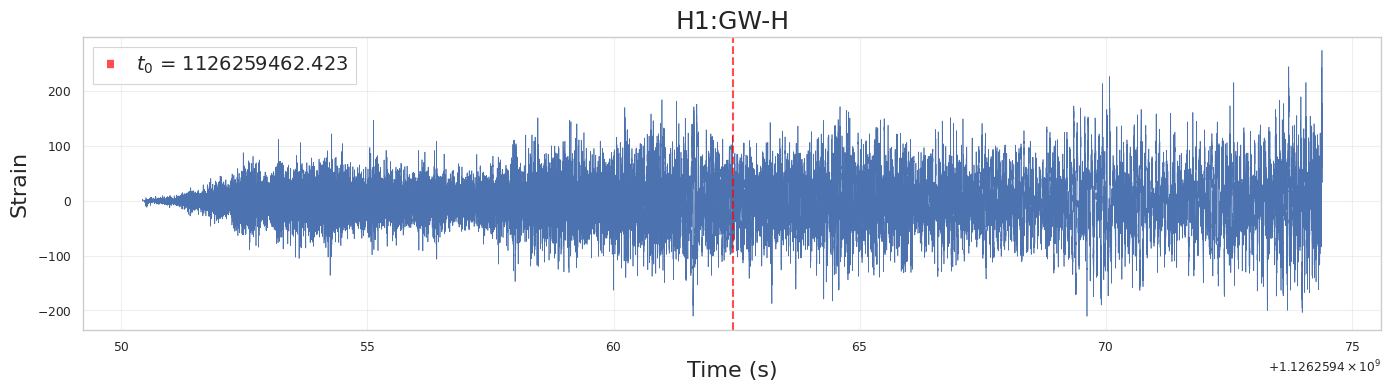

In [3]:
plt.figure(figsize=(14, 4))
plt.plot(ts.times.value, ts.value, linewidth=0.5)
plt.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5, label=f'$t_0$ = {t0_gps}', alpha=0.7)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Strain', fontsize=16)
plt.title(channel_name, fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
ts_scaled_cropped = ts * 1e-23 # scale
# make it 5 times louder
ts_scaled_cropped = ts_scaled_cropped * 5
ts_scaled_cropped = ts_scaled_cropped.crop(t0_gps, t0_gps + 4.0) # crop to first 4 seconds
ts_scaled_cropped

<TimeSeries([-3.72383321e-22, -3.89355626e-22, -8.49351010e-23,
             ..., -4.00392344e-21, -3.78804775e-21,
             -3.82201345e-21]
            unit=Unit("strain"),
            t0=<Quantity 1.12625946e+09 s>,
            dt=<Quantity 9.98973846e-05 s>,
            name='H1:GW-H',
            channel=None)>

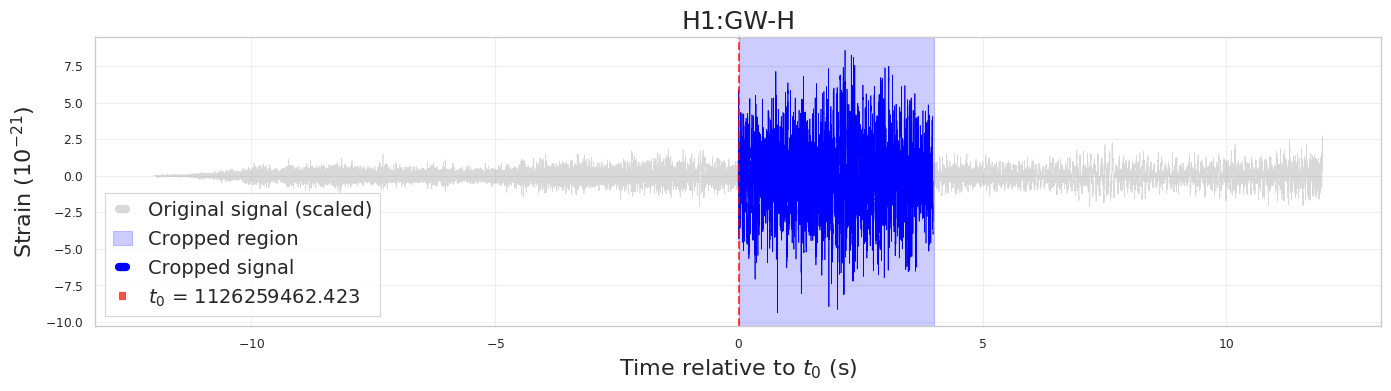

In [5]:
# Plot original and cropped signals
plt.figure(figsize=(14, 4))

time_relative_original = ts.times.value - t0_gps
plt.plot(time_relative_original, (ts * 1e-23).value / 1e-21, linewidth=0.5, alpha=0.3, color='gray', label='Original signal (scaled)')
# Shade the cropped region
plt.axvspan(0, 4.0, alpha=0.2, color='blue', label='Cropped region')

# Plot cropped signal
time_relative_cropped = ts_scaled_cropped.times.value - t0_gps
plt.plot(time_relative_cropped, ts_scaled_cropped.value / 1e-21, linewidth=0.5, color='blue', label='Cropped signal')
plt.xlabel('Time relative to $t_0$ (s)', fontsize=16)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label=f'$t_0$ = {t0_gps}', alpha=0.7)
plt.ylabel('Strain ($10^{-21}$)', fontsize=16)
plt.title(f'{channel_name}', fontsize=18)
plt.legend(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Add 2 seconds of zeros before and after the signal
n_zeros = int(2.0 * ts_scaled_cropped.sample_rate.value)  # 2 seconds of samples

# Create zero-padded data
padded_data = np.concatenate([np.zeros(n_zeros), ts_scaled_cropped.value, np.zeros(n_zeros)])

# Calculate t0 so that the middle of the padded signal is at t0_gps
n_padded_samples = len(padded_data)
padded_duration = (n_padded_samples - 1) / ts_scaled_cropped.sample_rate.value
t_start_padded = t0_gps - padded_duration / 2.0

# Create new TimeSeries with padded data
ts_padded = TimeSeries(padded_data, sample_rate=ts_scaled_cropped.sample_rate.value, 
                          t0=t_start_padded, name=channel_name, unit='strain')
ts_padded

<TimeSeries([0., 0., 0., ..., 0., 0., 0.]
            unit=Unit("strain"),
            t0=<Quantity 1.12625946e+09 s>,
            dt=<Quantity 9.98973846e-05 s>,
            name='H1:GW-H',
            channel=None)>

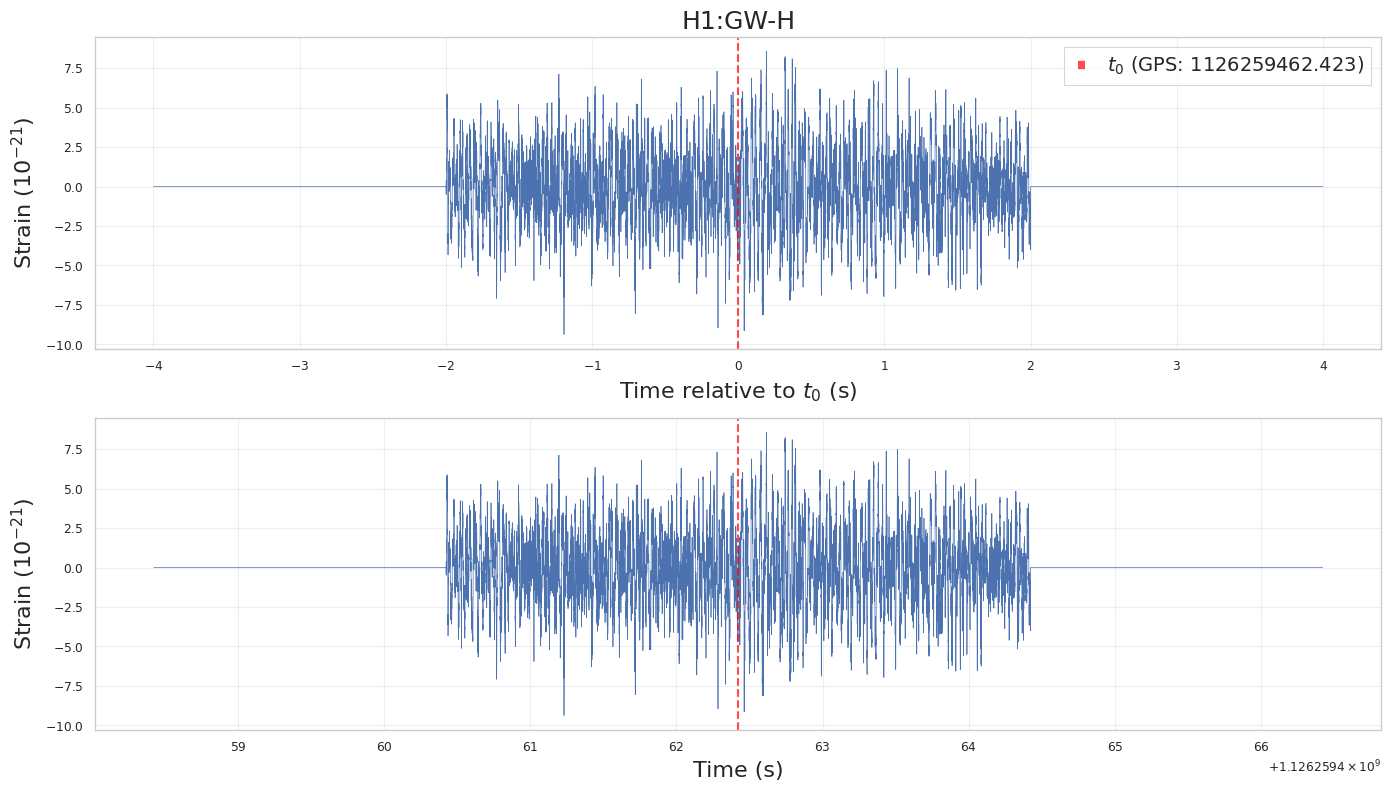

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot with relative time
time_relative = ts_padded.times.value - t0_gps
ax1.plot(time_relative, ts_padded.value/ 1e-21, linewidth=0.5)

ax1.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label=f'$t_0$ (GPS: {t0_gps})', alpha=0.7)
ax1.set_xlabel('Time relative to $t_0$ (s)', fontsize=16)
ax1.set_ylabel('Strain ($10^{-21}$)', fontsize=16)
ax1.set_title(f'{channel_name}', fontsize=18)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot with actual GPS time
ax2.plot(ts_padded.times.value, ts_padded.value / 1e-21, linewidth=0.5)
ax2.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5,alpha=0.7)
ax2.set_xlabel('Time (s)', fontsize=16)
ax2.set_ylabel('Strain ($10^{-21}$)', fontsize=16)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Save before decimation for comparison
ts_before_decimation = ts_padded.copy()
print(f"Before decimation: {ts_before_decimation.sample_rate.value} Hz, {len(ts_before_decimation)} samples")
print(f"t0 before decimation: {ts_before_decimation.t0.value}")

# Decimate to 4096 Hz using FIR filter to avoid phase shift
decimation_factor = int(ts_padded.sample_rate.value / 4096)
print(f"Decimation factor: {decimation_factor}")

# Use FIR filter with zero_phase=True to avoid time shift
data_decimated = signal.decimate(ts_padded.value, decimation_factor, ftype='fir', zero_phase=True)
ts_final = TimeSeries(data_decimated, sample_rate=4096, t0=ts_before_decimation.t0, name=channel_name, unit='strain')
ts_final = ts_final * signal.windows.tukey(len(ts_final), alpha=0.1)
print(f"After decimation: {ts_final.sample_rate.value} Hz, {len(ts_final)} samples")
print(f"t0 after decimation: {ts_final.t0.value}")

Before decimation: 10010.272076372315 Hz, 80040 samples
t0 before decimation: 1126259458.4251566
Decimation factor: 2
After decimation: 4096.0 Hz, 40020 samples
t0 after decimation: 1126259458.4251566


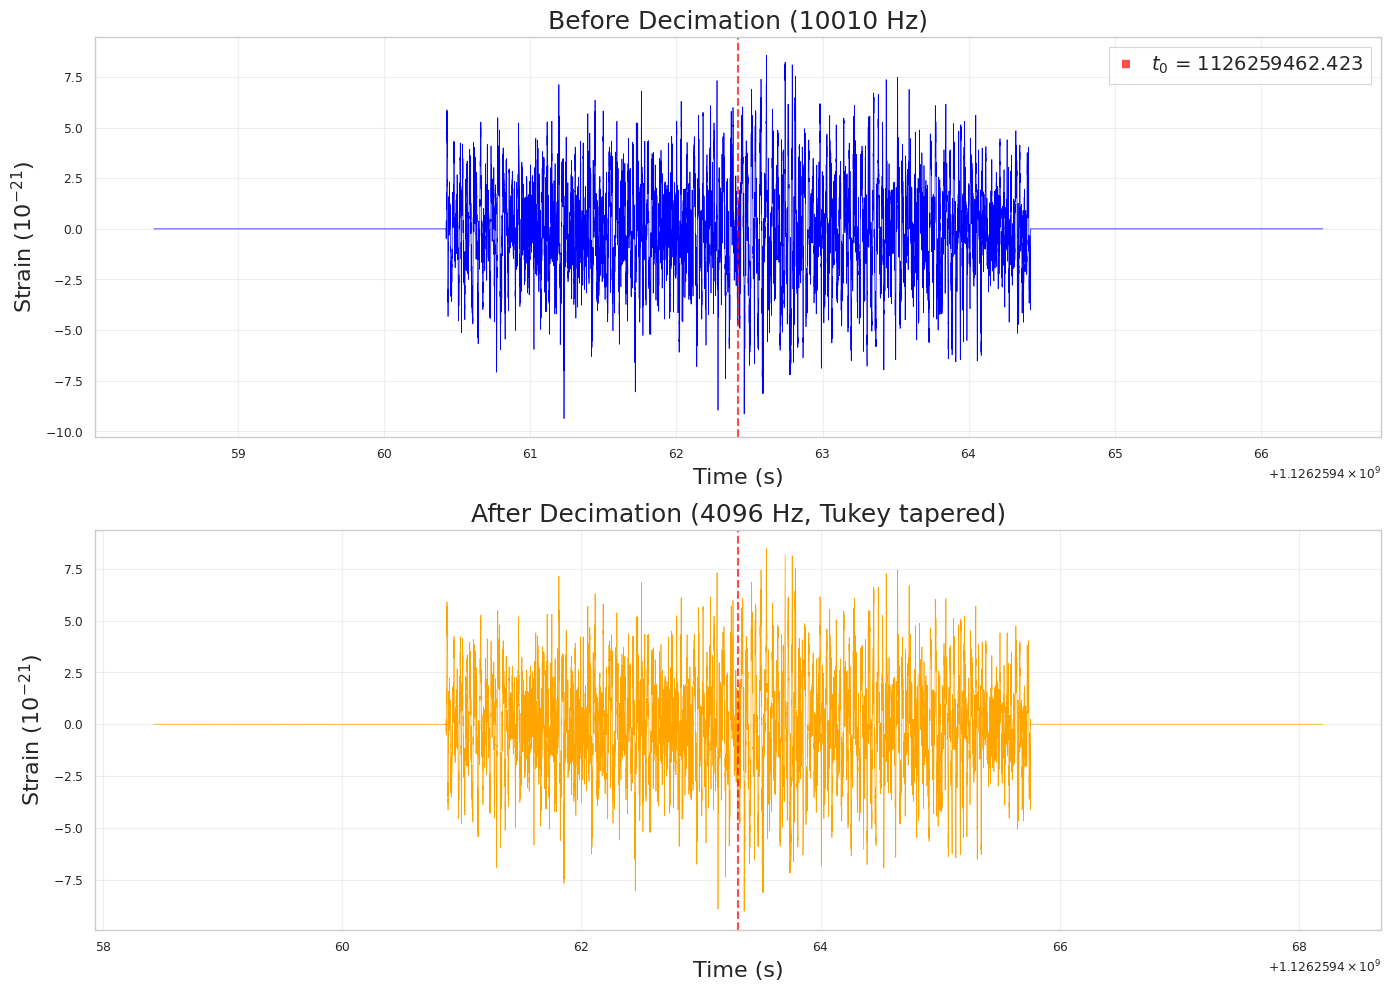

In [9]:
# Comparison plot with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Before decimation
ax1.plot(ts_before_decimation.times.value, ts_before_decimation.value / 1e-21, 
         linewidth=0.5, color='blue')
ax1.axvline(x=t0_gps, color='red', linestyle='--', linewidth=1.5, label=f'$t_0$ = {t0_gps}', alpha=0.7)
ax1.set_xlabel('Time (s)', fontsize=16)
ax1.set_ylabel('Strain ($10^{-21}$)', fontsize=16)
ax1.set_title(f'Before Decimation ({ts_before_decimation.sample_rate.value:.0f} Hz)', fontsize=18)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)

# After decimation
ax2.plot(ts_final.times.value, ts_final.value / 1e-21, 
         linewidth=0.5, color='orange')
ax2.axvline(x=ts_final.t0.value + (ts_final.duration.value / 2), color='red', linestyle='--', linewidth=1.5, label=f'$t_0$ = {t0_gps}', alpha=0.7)
ax2.set_xlabel('Time (s)', fontsize=16)
ax2.set_ylabel('Strain ($10^{-21}$)', fontsize=16)
ax2.set_title(f'After Decimation (4096 Hz, Tukey tapered)', fontsize=18)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
ts_final.write('H1.gwf', format='gwf')
print(f"Written {len(ts_final)} samples at {ts_final.sample_rate.value} Hz to Frame.gwf")
print(f"Total duration: {ts_final.duration.value} seconds")

Written 40020 samples at 4096.0 Hz to Frame.gwf
Total duration: 9.7705078125 seconds


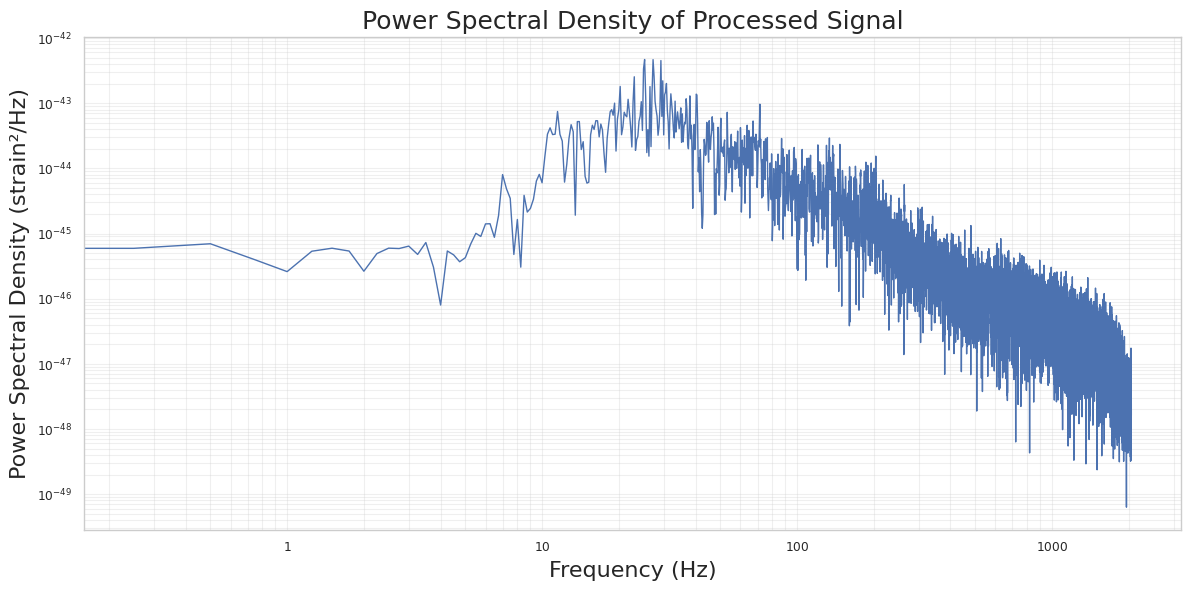

PSD calculated with 4s FFT length and 2s overlap
Frequency resolution: 0.25 Hz


In [11]:
# Calculate PSD (Power Spectral Density) w/ Welch's method
fftlength = 4  # FFT length in seconds
overlap = 2    # Overlap in seconds

psd = ts_final.psd(fftlength=fftlength, overlap=overlap)

# Plot PSD
plt.figure(figsize=(12, 6))
plt.loglog(psd.frequencies.value, psd.value, linewidth=1)
plt.xlabel('Frequency (Hz)', fontsize=16)
plt.ylabel('Power Spectral Density (strain²/Hz)', fontsize=16)
plt.title('Power Spectral Density of Processed Signal', fontsize=18)
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f"PSD calculated with {fftlength}s FFT length and {overlap}s overlap")
print(f"Frequency resolution: {psd.df.value} Hz")

# Save PSD
np.savetxt('psd.dat', np.column_stack([psd.frequencies.value, psd.value]), 
           header='Frequency (Hz), PSD (strain^2/Hz)', delimiter=' ')